# Task 3 - Cognitive load and the data-ink ratio

Data: `car_crashes.csv` (50 states + DC), `tips.csv`.

`total` = drivers involved in fatal collisions per billion miles. I only plot `total`. The other columns are in % and dollars, and putting them on the same axis would break the Week 1 rule.

In [1]:
%matplotlib inline

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

GREY = "#bbbbbb"
GREY_DARK = "#777777"
ACCENT = "#ee6677"
BLUE = "#4477aa"
INK = "#222222"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.edgecolor": GREY_DARK,
    "xtick.color": GREY_DARK,
    "ytick.color": GREY_DARK,
})


def declutter(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


def save(fig, name):
    fig.savefig(CHARTS / f"{name}.png", dpi=300, bbox_inches="tight")

import matplotlib.patheffects as pe

In [2]:
crash = pd.read_csv(DATA / "car_crashes.csv")
crash[["abbrev", "total"]].describe()

,total
count,51.000000
mean,15.790196
std,4.122002
min,5.900000
25%,12.750000
50%,15.600000
75%,18.500000
max,23.900000


## 1. The overloaded chart (on purpose)

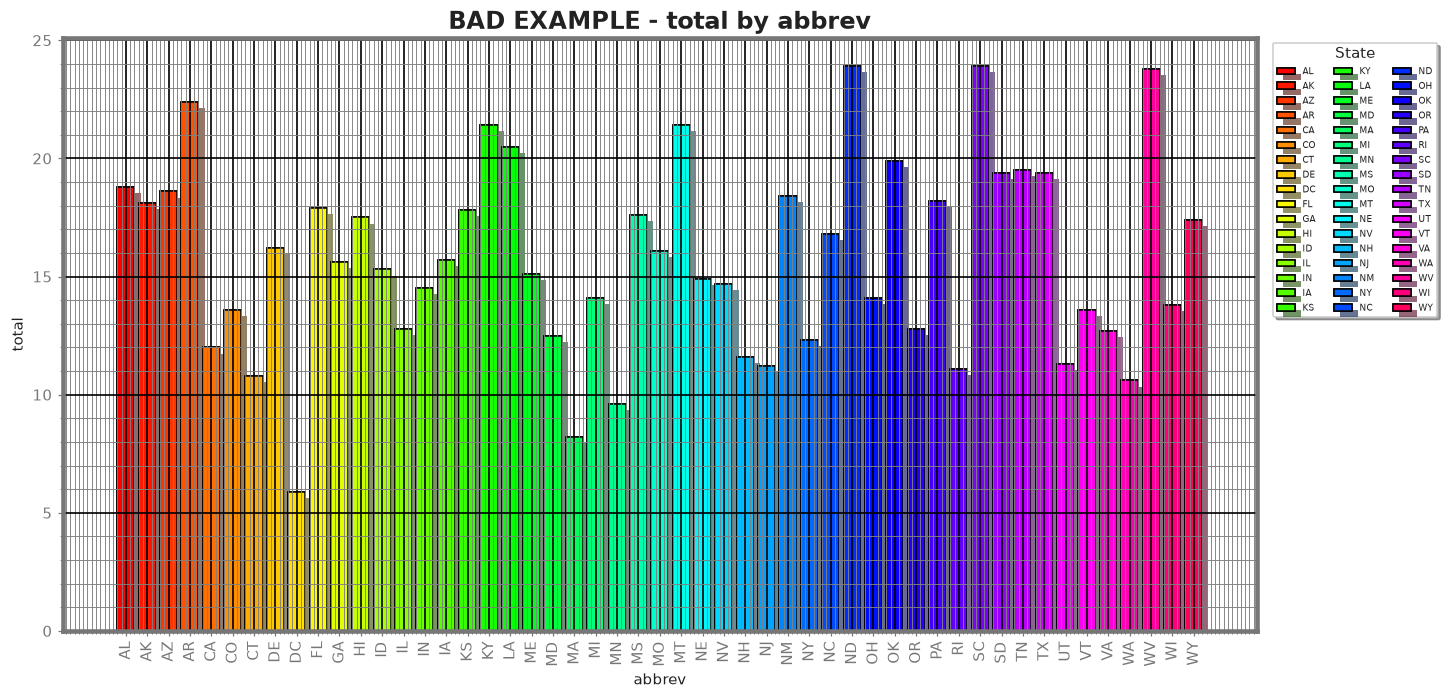

In [3]:
rainbow = plt.cm.hsv(np.linspace(0, 0.95, len(crash)))

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(crash["abbrev"], crash["total"], color=rainbow, edgecolor="black", linewidth=1)
for b in bars:
    b.set_path_effects([pe.withSimplePatchShadow(offset=(4, -4), alpha=0.6), pe.Normal()])
ax.minorticks_on()
ax.grid(True, which="major", color="black", linewidth=1.1)
ax.grid(True, which="minor", color="grey", linewidth=0.6)
for s in ax.spines.values():
    s.set_linewidth(3)
ax.tick_params(axis="x", rotation=90)
ax.legend(bars, crash["abbrev"], ncol=3, fontsize=6, title="State",
          loc="upper left", bbox_to_anchor=(1.01, 1), shadow=True)
ax.set_title("BAD EXAMPLE - total by abbrev", loc="center", fontsize=16)
ax.set_xlabel("abbrev")
ax.set_ylabel("total")
save(fig, "task3_bad_overloaded")
plt.show()

## 2. Counting the load

| Element | Type | Why |
|---|---|---|
| 51 states, one value each | intrinsic | that's the data, it's big and can't be made smaller without hiding something |
| 51 bar heights | germane | the only marks that encode a number. Comparing them is the actual job |
| y-axis tick values | germane | needed to read how big the numbers are |
| 51 state labels on x | germane, but costly | needed to say which bar is which, but rotated 90 degrees so every one has to be read sideways |
| 51 different colours | extraneous | colour means nothing here, every bar already has a position. The eye still tries to find a pattern in it |
| legend with 51 entries | extraneous | repeats the x labels. Worse, it invites matching colours by eye (51 hues, many look alike) |
| drop shadows | extraneous | double the bar edges, make the height harder to read |
| heavy major + minor grid, both directions | extraneous | vertical lines carry nothing at all. Horizontal ones are so heavy they compete with the bars |
| thick box frame | extraneous | top and right spines don't mean anything |
| bar outlines | extraneous | doubling the bar edge |
| unsorted (alphabetical) order | extraneous | to find the highest state the reader has to scan all 51 and remember the max |
| title "total by abbrev" + axis labels "total", "abbrev" | extraneous | just the column names: no units, no finding. The reader has to guess what "total" is |

**Data-ink ratio.** I counted marks straight from the figure objects below. A "mark that encodes a number" = a bar. Everything else is a non-data mark. Shadows count as one mark per bar, and so do the legend swatch and the legend text.

In [4]:
n_bars = len(bars)
counts = {
    "bars (data)": n_bars,
    "bar shadows": n_bars,
    "bar outlines": n_bars,
    "legend swatches": n_bars,
    "legend labels": n_bars,
    "legend frame + title + shadow": 3,
    "x tick labels": len(ax.get_xticklabels()),
    "x tick marks (major + minor)": len(ax.xaxis.get_majorticklocs()) + len(ax.xaxis.get_minorticklocs()),
    "vertical gridlines (major + minor)": len(ax.xaxis.get_majorticklocs()) + len(ax.xaxis.get_minorticklocs()),
    "y tick labels": len([t for t in ax.get_yticklabels() if t.get_text()]),
    "y tick marks (major + minor)": len(ax.yaxis.get_majorticklocs()) + len(ax.yaxis.get_minorticklocs()),
    "horizontal gridlines (major + minor)": len(ax.yaxis.get_majorticklocs()) + len(ax.yaxis.get_minorticklocs()),
    "frame (4 spines)": 4,
    "title + 2 axis labels": 3,
}
ink = pd.Series(counts, name="marks")
display(ink.to_frame())
total_marks = ink.sum()
print(f"data marks / total marks = {n_bars} / {total_marks} = {n_bars / total_marks:.2f}")

,marks
bars (data),51
bar shadows,51
bar outlines,51
legend swatches,51
legend labels,51
legend frame + title + shadow,3
x tick labels,51
x tick marks (major + minor),281
vertical gridlines (major + minor),281
y tick labels,7


data marks / total marks = 51 / 939 = 0.05


So only about one mark in twenty is data. The minor ticks are the worst part: on a categorical axis matplotlib draws hundreds of them, and every one gets its own gridline. The rest is decoration or repeated information. It's an estimate: I'm counting marks, not actual pixels of ink. A thick bar is more ink than a thin gridline, so by area the ratio is a bit better than this, but the order of magnitude is the point.

## 3. Stripping it down, one step at a time

The order I used:
1. remove the legend - biggest single block of junk, and it repeats the x labels
2. remove the frame, the shadows and the vertical gridlines - none of them hold any value. I removed the shadows here because they are basically a second frame around every bar
3. one hue - the colours never meant anything
4. sort - the biggest win, and it adds no ink at all
5. label only what matters - one pop-out for the message, the rest stays grey

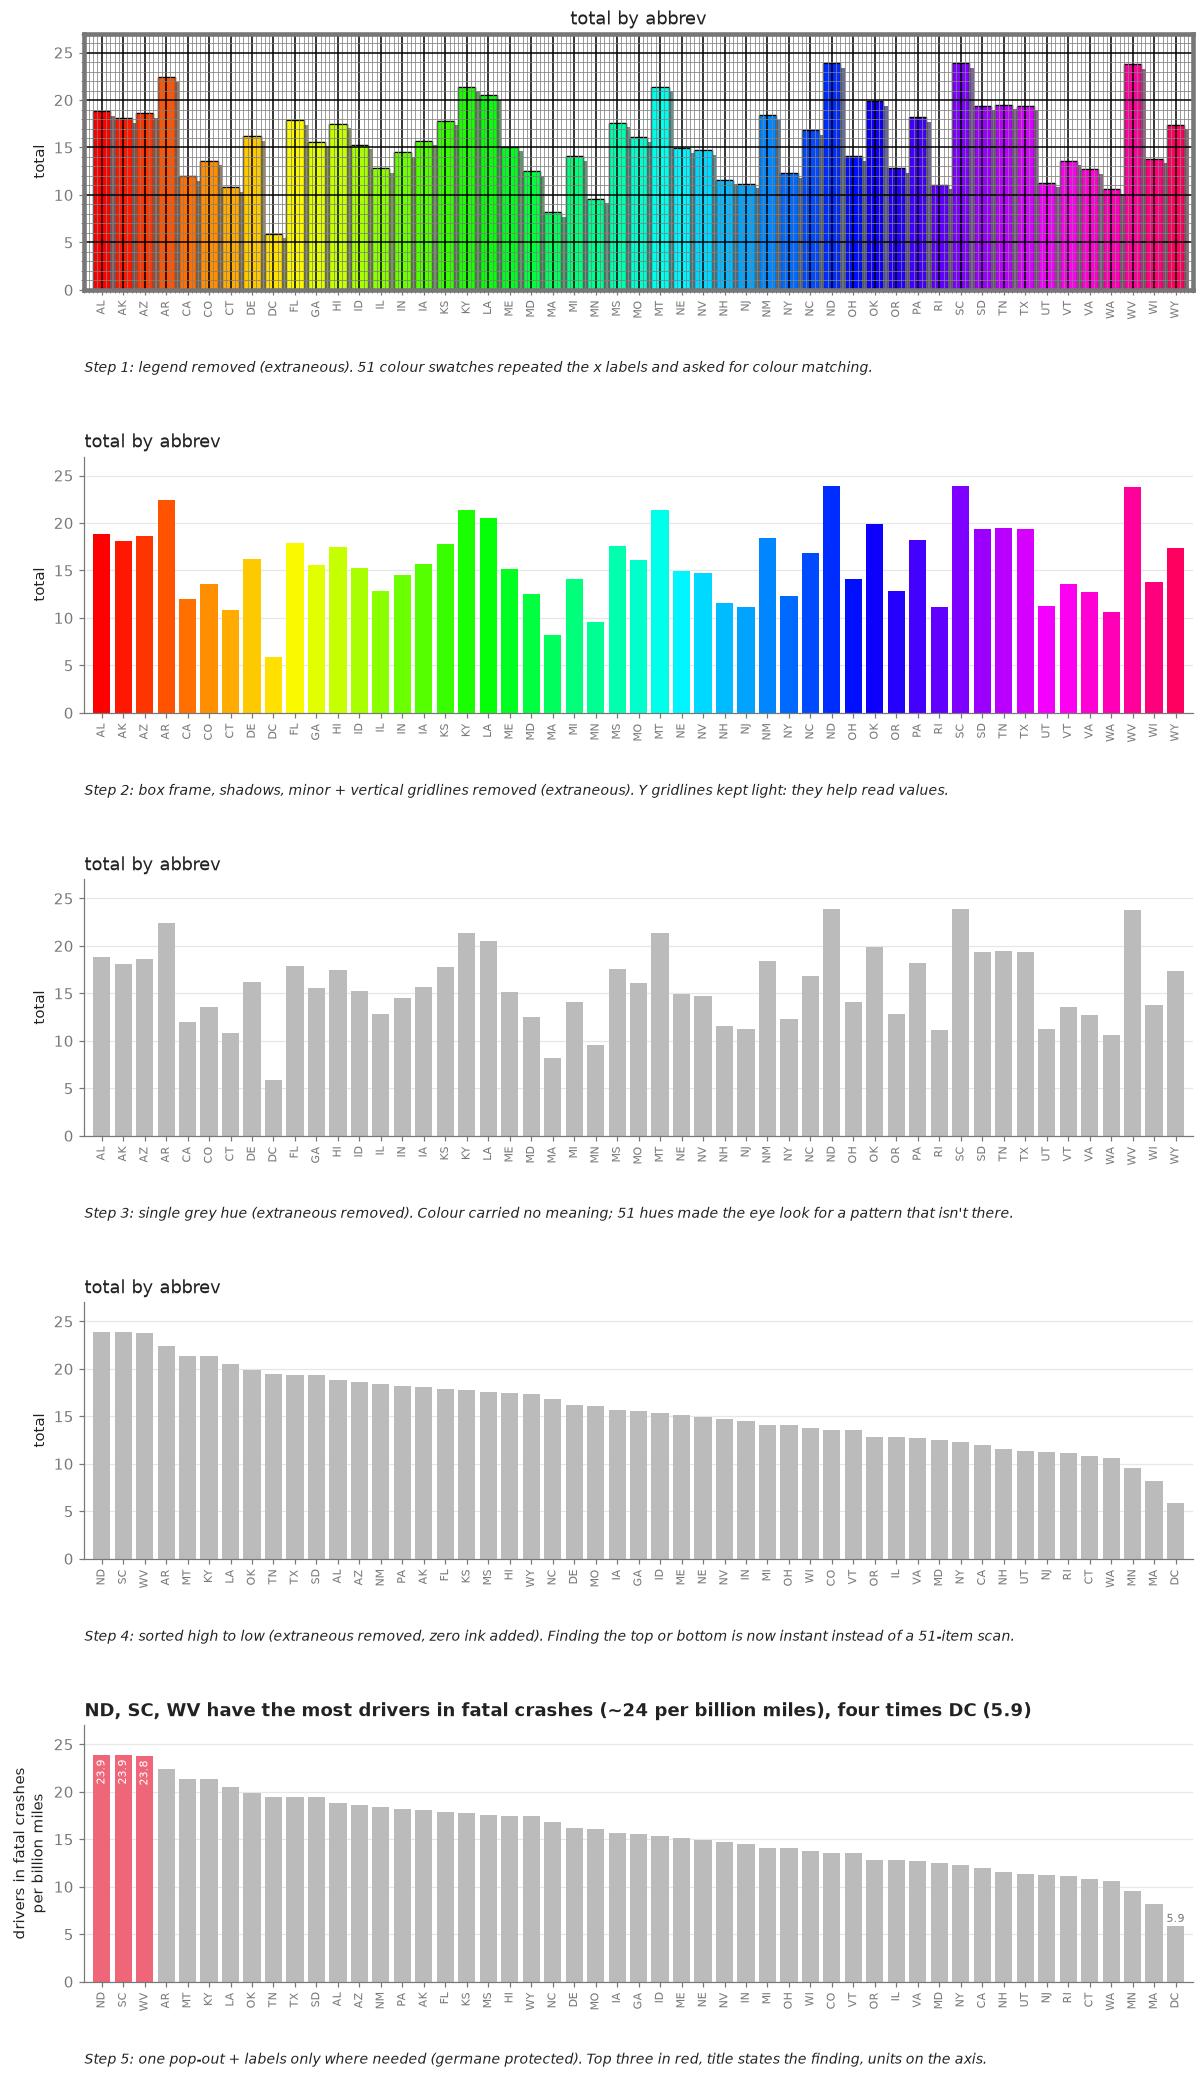

In [5]:
order_alpha = crash.reset_index(drop=True)
order_sorted = crash.sort_values("total", ascending=False).reset_index(drop=True)
top3 = order_sorted.head(3)["abbrev"].tolist()

CAPTIONS = [
    "Step 1: legend removed (extraneous). 51 colour swatches repeated the x labels and asked for colour matching.",
    "Step 2: box frame, shadows, minor + vertical gridlines removed (extraneous). Y gridlines kept light: they help read values.",
    "Step 3: single grey hue (extraneous removed). Colour carried no meaning; 51 hues made the eye look for a pattern that isn't there.",
    "Step 4: sorted high to low (extraneous removed, zero ink added). Finding the top or bottom is now instant instead of a 51-item scan.",
    "Step 5: one pop-out + labels only where needed (germane protected). Top three in red, title states the finding, units on the axis.",
]


def step_chart(ax, step):
    df = order_sorted if step >= 4 else order_alpha
    if step <= 2:
        colours = rainbow
    elif step < 5:
        colours = [GREY] * len(df)
    else:
        colours = [ACCENT if a in top3 else GREY for a in df["abbrev"]]
    edge = "black" if step == 1 else "none"
    b = ax.bar(df["abbrev"], df["total"], color=colours, edgecolor=edge, linewidth=0.8)
    if step == 1:
        for bar in b:
            bar.set_path_effects([pe.withSimplePatchShadow(offset=(3, -3), alpha=0.6), pe.Normal()])
        ax.minorticks_on()
        ax.grid(True, which="major", color="black", linewidth=1)
        ax.grid(True, which="minor", color="grey", linewidth=0.5)
        for s in ax.spines.values():
            s.set_linewidth(3)
    else:
        ax.grid(axis="y", color="#e6e6e6")
        ax.set_axisbelow(True)
        declutter(ax)
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.set_xlim(-0.8, len(df) - 0.2)
    ax.set_ylim(0, 27)
    if step < 5:
        ax.set_ylabel("total")
        ax.set_title("total by abbrev", loc="center" if step == 1 else "left", fontweight="normal")
    else:
        ax.set_ylabel("drivers in fatal crashes\nper billion miles")
        lo = order_sorted.iloc[-1]
        ax.set_title(f"{', '.join(top3)} have the most drivers in fatal crashes "
                     f"(~{order_sorted['total'].iloc[0]:.0f} per billion miles), "
                     f"four times {lo['abbrev']} ({lo['total']:.1f})")
        for i, row in order_sorted.iterrows():
            if row["abbrev"] in top3:
                ax.text(i, row["total"] - 0.5, f"{row['total']:.1f}", ha="center", va="top",
                        fontsize=7, rotation=90, color="white")
        ax.text(len(df) - 1, order_sorted["total"].iloc[-1] + 0.4, f"{order_sorted['total'].iloc[-1]:.1f}",
                ha="center", fontsize=7, color=GREY_DARK)
    ax.text(0, -0.32, CAPTIONS[step - 1], transform=ax.transAxes, fontsize=9, color=INK, style="italic")


fig, axes = plt.subplots(5, 1, figsize=(13, 23))
for i, ax in enumerate(axes, start=1):
    step_chart(ax, i)
fig.subplots_adjust(hspace=0.65)
save(fig, "task3_five_step_strip")
plt.show()

What each step removed:

| Step | Removed | Kind of load |
|---|---|---|
| 1 | legend (51 entries) | extraneous - pure lookup work, repeated the x labels |
| 2 | frame, shadows, minor grid, vertical grid | extraneous - none of these carry a value. I kept faint horizontal lines on purpose, they help read heights |
| 3 | 51 hues → 1 grey | extraneous - the reader stops looking for meaning in colour |
| 4 | alphabetical order → sorted | extraneous - removed a 51-item search. **Adds zero ink** and is the biggest improvement of the five |
| 5 | generic title, column-name axis label | extraneous swapped for germane: the title now says the finding, the axis has units, value labels only on the four bars the title mentions |

Step 5 has one pop-out (the top three, as one group, in red), and that's exactly what the title talks about. DC is labelled in grey so the "four times" claim can be checked, but it doesn't pop out.

## 4. Respecting the 4 ± 1 limit

Chunking: the four US Census regions. The reader holds four things (Northeast, Midwest, South, West) instead of 51. Bars are region medians, starting at zero. Each grey dot is one state, so the spread inside a region isn't completely lost.

In [6]:
REGIONS = {
    "Northeast": "CT ME MA NH RI VT NJ NY PA",
    "Midwest": "IL IN MI OH WI IA KS MN MO NE ND SD",
    "South": "DE FL GA MD NC SC VA DC WV AL KY MS TN AR LA OK TX",
    "West": "AZ CO ID MT NV NM UT WY AK CA HI OR WA",
}
region_of = {s: r for r, states in REGIONS.items() for s in states.split()}
crash["region"] = crash["abbrev"].map(region_of)
assert crash["region"].notna().all()

reg = crash.groupby("region")["total"].agg(["median", "size"]).sort_values("median")
reg

,median,size
region,,
Northeast,11.6,9
Midwest,14.7,12
West,15.3,13
South,18.8,17


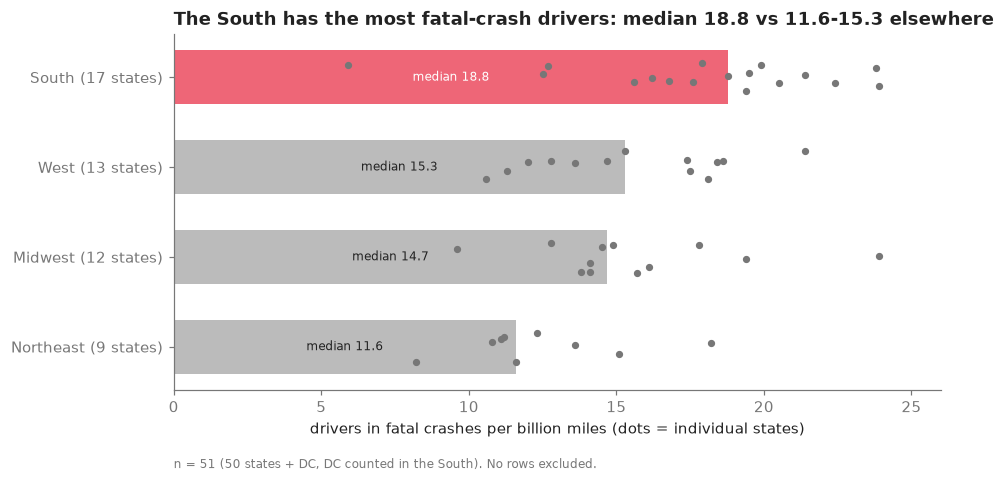

In [7]:
top_region = reg.index[-1]
rest = reg.drop(top_region)

fig, ax = plt.subplots(figsize=(9, 4.2))
y = np.arange(len(reg))
ax.barh(y, reg["median"], color=[ACCENT if r == top_region else GREY for r in reg.index], height=0.6)
jitter = np.random.default_rng(0)
for i, r in enumerate(reg.index):
    vals = crash.loc[crash["region"] == r, "total"]
    ax.scatter(vals, i + jitter.uniform(-0.18, 0.18, len(vals)), s=14, color=GREY_DARK, zorder=3)
    ax.text(reg.loc[r, "median"] / 2, i, f"median {reg.loc[r, 'median']:.1f}", va="center",
            ha="center", fontsize=8, color="white" if r == top_region else INK)
ax.set_yticks(y)
ax.set_yticklabels([f"{r} ({reg.loc[r, 'size']} states)" for r in reg.index])
ax.set_xlim(0, 26)
ax.set_xlabel("drivers in fatal crashes per billion miles (dots = individual states)")
ax.set_title(f"The {top_region} has the most fatal-crash drivers: median {reg.loc[top_region, 'median']:.1f} "
             f"vs {rest['median'].min():.1f}-{rest['median'].max():.1f} elsewhere")
declutter(ax)
ax.text(0, -0.22, "n = 51 (50 states + DC, DC counted in the South). No rows excluded.",
        transform=ax.transAxes, fontsize=8, color=GREY_DARK)
save(fig, "task3_regions_chunked")
plt.show()

Four chunks, one pop-out (the highest region in red), position/length for the number. Grouping is by **proximity**: each region's dots sit on its own row.

What this hides: the individual state names. A reader can't tell which dot is Montana or how a given state ranks against all the others. Medians also hide the spread inside a region. The West, for example, goes from Washington (10.6) to Montana (21.4), and the median makes it look more uniform than it is. The dots win back some of that, but not the names. Census regions are also an administrative choice. A different grouping (rural vs urban states) would probably tell a different story.

## 5. Over-stripping

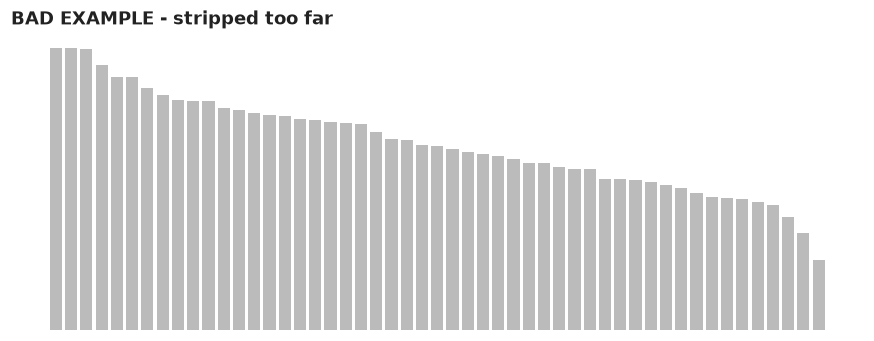

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(len(order_sorted)), order_sorted["total"], color=GREY)
ax.axis("off")
ax.set_title("BAD EXAMPLE - stripped too far")
save(fig, "task3_bad_overstripped")
plt.show()

This one has a near-perfect data-ink ratio: almost every pixel is a bar. But nobody can tell what it shows: no states, no units, no scale, not even what is being measured. All the reader can see is "something goes down". The germane parts (labels, units, a value scale) were thrown out along with the junk. That's why the ratio isn't something you push to the max.

**Stopping rule:** stop removing ink once a reader can no longer tell what is measured, in what units, and which mark is which from the chart alone.

## The question: adding ink that lowers load (`tips.csv`)

Tip vs bill as a scatter. Without help, the reader has to do the division in their head for every point to know if a tip is "good". Three reference lines (10%, 15%, 20% of the bill) add ink but take that calculation away: you just see which band a dot falls in.

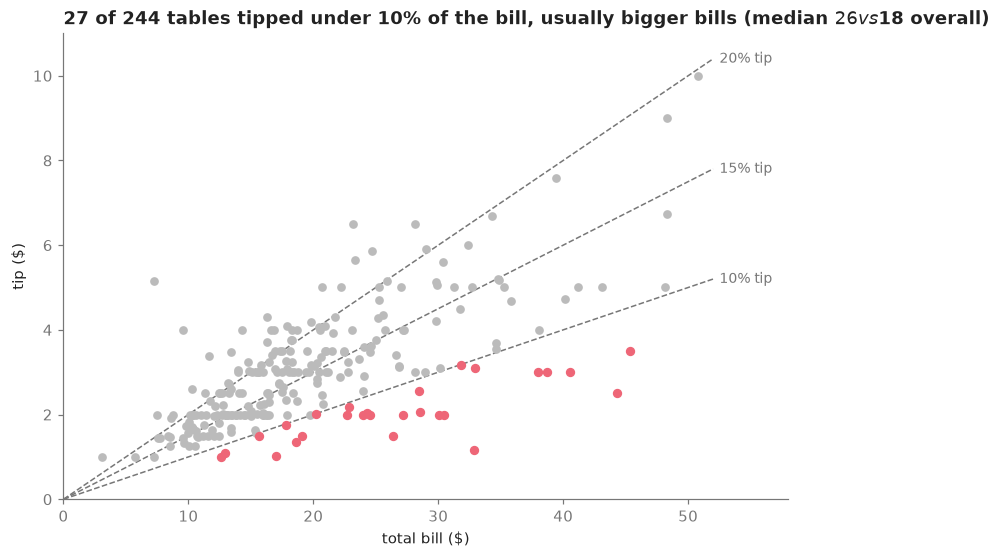

In [9]:
tips = pd.read_csv(DATA / "tips.csv")
tips["pct"] = tips["tip"] / tips["total_bill"] * 100
low = tips[tips["pct"] < 10]
rest = tips[tips["pct"] >= 10]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
xs = np.array([0, 52])
for rate in (0.10, 0.15, 0.20):
    ax.plot(xs, xs * rate, color=GREY_DARK, linewidth=1, linestyle="--", zorder=1)
    ax.text(52.5, 52 * rate, f"{rate:.0%} tip", va="center", fontsize=9, color=GREY_DARK)
ax.scatter(rest["total_bill"], rest["tip"], s=22, color=GREY, zorder=2)
ax.scatter(low["total_bill"], low["tip"], s=26, color=ACCENT, zorder=3)
ax.set_xlim(0, 58)
ax.set_ylim(0, 11)
ax.set_xlabel("total bill ($)")
ax.set_ylabel("tip ($)")
ax.set_title(f"{len(low)} of {len(tips)} tables tipped under 10% of the bill, "
             f"usually bigger bills (median ${low['total_bill'].median():.0f} vs ${tips['total_bill'].median():.0f} overall)")
declutter(ax)
save(fig, "task3_tips_reference_lines")
plt.show()

Three dashed lines and three labels are pure added ink. In data-ink terms the chart got "worse". But each line answers "what percentage is this tip?" for every dot at once, which would otherwise be 244 mental divisions. The red dots are the single pop-out and the title is about them. They sit below the 10% line, so they're also marked by position, not just by colour.

So "maximise data-ink" is a heuristic. It's good for catching junk (frames, shadows, rainbow fills), but the real target is reader effort, not ink. If a piece of non-data ink saves the reader a calculation or a lookup, it's lowering extraneous load, and it should stay.